In [1]:
!pip install ultralytics

   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   ------------------------------ --------- 1.0/1.4 MB 8.2 MB/s eta 0:00:01
   ---------------------------------------- 1.4/1.4 MB 7.0 MB/s  0:00:00
   ---------------------------------------- 0.0/44.0 MB ? eta -:--:--
   - -------------------------------------- 1.8/44.0 MB 8.8 MB/s eta 0:00:05
   --- ------------------------------------ 3.7/44.0 MB 8.9 MB/s eta 0:00:05
   ---- ----------------------------------- 5.2/44.0 MB 8.7 MB/s eta 0:00:05
   ------ --------------------------------- 6.8/44.0 MB 8.6 MB/s eta 0:00:05
   ------- -------------------------------- 8.4/44.0 MB 8.4 MB/s eta 0:00:05
   -------- ------------------------------- 9.7/44.0 MB 7.7 MB/s eta 0:00:05
   ---------- ----------------------------- 11.3/44.0 MB 8.1 MB/s eta 0:00:05
   ---------- ----------------------------- 12.1/44.0 MB 7.2 MB/s eta 0:00:05
   ------------ --------------------------- 13.6/44.0 MB 7.5 MB/s eta 0:00:05
   -------------


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Creating new Ultralytics Settings v0.0.6 file  
View Ultralytics Settings with 'yolo settings' or at 'C:\Users\Hp\AppData\Roaming\Ultralytics\settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
YOLOv8 loaded
Test image saved to test_image.jpg

image 1/1 c:\Users\Hp\.vscode\Journey to the BEST\Week 6\test_image.jpg: 384x640 2 persons, 1 tie, 184.6ms
Speed: 6.3ms preprocess, 184.6ms inference, 12.2ms postprocess per image at shape (1, 3, 384, 640)

=== Detections ===
  person         : 0.84 confidence
  person         : 0.82 confidence
  tie            : 0.29 confidence


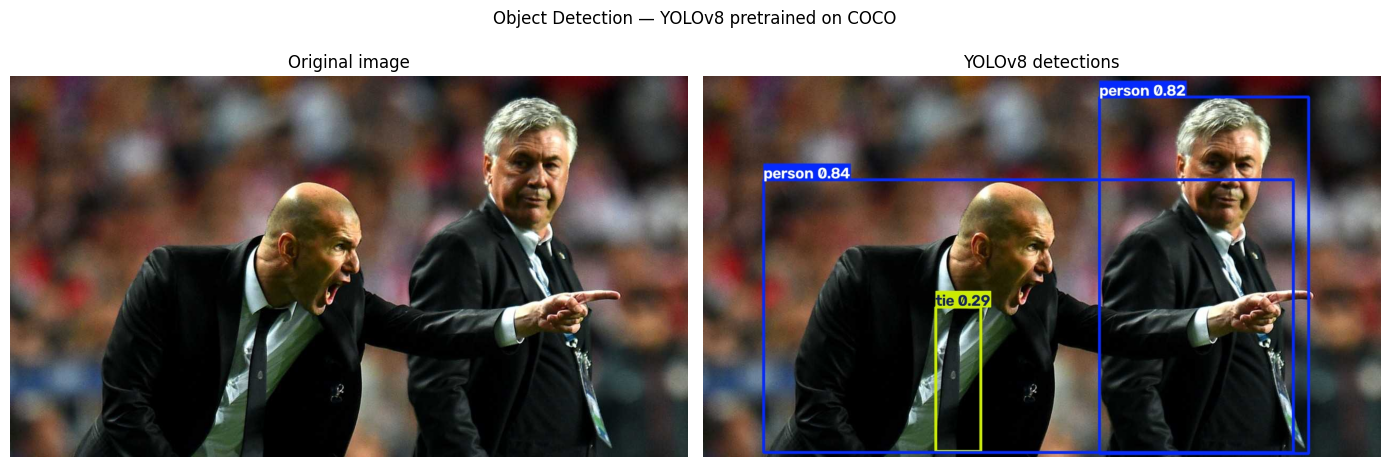

In [2]:
# Detection = classification + localisation

# YOLO (You Only Look Once) — real-time object detection

from ultralytics import YOLO
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import urllib.request
import os

# ── Load pretrained YOLOv5 model ─────────────────────────
# 'yolov8n' = nano version, fastest, smallest
model = YOLO('yolov8n.pt')   # downloads automatically
print("YOLOv8 loaded")

# ── Download a test image ─────────────────────────────────
url      = "https://ultralytics.com/images/zidane.jpg"
img_path = "test_image.jpg"
urllib.request.urlretrieve(url, img_path)
print(f"Test image saved to {img_path}")

# ── Run detection ─────────────────────────────────────────
results = model(img_path)

# ── Show results ──────────────────────────────────────────
results[0].show()   # opens image with bounding boxes

# Print what was detected
print("\n=== Detections ===")
for box in results[0].boxes:
    cls_id     = int(box.cls)
    cls_name   = model.names[cls_id]
    confidence = float(box.conf)
    print(f"  {cls_name:15s}: {confidence:.2f} confidence")

# ── Save result image ──────────────────────────────────────
results[0].save('detection_result.jpg')

# Display in notebook
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.imshow(mpimg.imread(img_path))
ax1.set_title('Original image')
ax1.axis('off')

ax2.imshow(mpimg.imread('detection_result.jpg'))
ax2.set_title('YOLOv8 detections')
ax2.axis('off')

plt.suptitle('Object Detection — YOLOv8 pretrained on COCO',
             fontsize=12)
plt.tight_layout()
plt.show()